In [2]:
import numpy as np
from scipy.stats import unitary_group

import random
from random import choices

from functools import partial
from itertools import product, combinations
from opt_einsum import contract

import qutip as qt

import pandas as pd

import jax
import jax.numpy as jnp

import time
import os

from circuits import maxEntangle_state, seqModel_RA_vec, seqModel_RAmc, seqModelTraceOut_RA_vec
from haar_theory import avgS2, MIR2_traceout

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib import rc
from matplotlib.legend_handler import HandlerTuple
rc('text', usetex=True)
rc('font', size=25)
rc('axes', linewidth=3)
rc('text.latex', preamble=r'\usepackage{amsfonts}')
rc('text.latex', preamble=r'\usepackage{bm}')

# measuremend-conditioned

In [62]:
# von-Neumann entropy and purity (exact calculation)
num = 10

Na = 3
Nb = 1

# exact calculation
probsB = []
probs_RA = []
for t in range(1, 16):
    t0 = time.time()
    zs = np.array(list(product(range(2**Nb), repeat=t))).astype(np.int8)
    
    each_prB = jnp.zeros((num, 2**(Nb*t)))
    each_prRA = jnp.zeros((num, 2**(Nb*t), 4**Na))
    for j in range(num):
        np.random.seed(1+j)
        Us = unitary_group.rvs(dim=2**(Na+Nb), size=t).reshape(t, 2**(Na+Nb), 2**(Na+Nb))
        
        res = seqModel_RA_vec(zs, Us, Na, Nb, t)
        
        each_prB = each_prB.at[j].set(jnp.prod(res[0], axis=1))
        each_prRA = each_prRA.at[j].set(jnp.abs(res[1])**2)

    probsB.append(each_prB)
    probs_RA.append(each_prRA)
    print(f'Nb={Nb}, step={t}, time={(time.time() - t0):.2f}')

np.savez(f'data/Q2C/MI/probsB_Na{Na}Nb{Nb}_ex.npz', *probsB)
np.savez(f'data/Q2C/MI/probsRA_Na{Na}Nb{Nb}_ex.npz', *probs_RA)

Nb=1, step=1, time=1.34
Nb=1, step=2, time=0.51
Nb=1, step=3, time=0.58
Nb=1, step=4, time=0.66
Nb=1, step=5, time=0.79
Nb=1, step=6, time=0.84
Nb=1, step=7, time=0.99
Nb=1, step=8, time=1.13
Nb=1, step=9, time=1.39
Nb=1, step=10, time=1.66
Nb=1, step=11, time=1.92
Nb=1, step=12, time=2.45
Nb=1, step=13, time=3.64
Nb=1, step=14, time=6.83
Nb=1, step=15, time=12.00


# Result

In [66]:
probsB = np.load(f'data/Q2C/MI/probsB_Na{Na}Nb{Nb}_ex.npz')
probsRA = np.load(f'data/Q2C/MI/probsRA_Na{Na}Nb{Nb}_ex.npz')
probsB = [probsB[f'arr_{i}'] for i in range(15)]
probsRA = [probsRA[f'arr_{i}'] for i in range(15)]

In [67]:
def condCMI(probsRA, Na):
    df = pd.DataFrame(probsRA)

    df.index.name = 'z_B' 
    df.columns.name = 'z_RA'

    # construct z_RA index
    binary_columns = [format(j, f'0{2*Na}b') for j in range(probsRA.shape[1])]
    df.columns = binary_columns
    
    # calculate marginal distribution of z_R and z_A for each z_B
    P_R = np.zeros((probsRA.shape[0], 2**Na))
    P_A = np.zeros((probsRA.shape[0], 2**Na))
    for k in range(2**Na):
        s = format(k, f'0{Na}b')
        R_filtered_df = df.loc[:, [col[:Na] == s for col in df.columns]]
        A_filtered_df = df.loc[:, [col[Na:] == s for col in df.columns]]
        P_R[:, k] = R_filtered_df.sum(axis=1)
        P_A[:, k] = A_filtered_df.sum(axis=1)

    # calculate classical mutual information
    CMI = np.zeros((probsRA.shape[0], 4**Na))
    for cc, (z_R, z_A) in enumerate(product(range(2**Na), repeat=2)):
        s_RA = format(z_R, f'0{Na}b') + format(z_A, f'0{Na}b')
        pr_RA = np.array(df[s_RA])
        CMI[:, cc] = pr_RA * np.log2(pr_RA/(P_R[:, z_R]*P_A[:, z_A]))
    CMI = CMI.sum(1)
    return CMI


In [68]:
def uncondCMI(probsB, probsRA, Na):
    probsRA_uncond = (probsB[:, np.newaxis] * probsRA).sum(0)
    
    binary_rows = [format(j, f'0{2*Na}b') for j in range(probsRA.shape[1])]
    df = pd.DataFrame(probsRA_uncond, index=binary_rows)
    
    # calculate marginal distribution of z_R and z_A for each z_B
    P_R = np.zeros(2**Na)
    P_A = np.zeros(2**Na)
    for k in range(2**Na):
        s = format(k, f'0{Na}b')
        
        R_filtered_df = df[df.index.str.startswith(s)]
        A_filtered_df = df[df.index.str.endswith(s)]
        
        P_R[k] = float(R_filtered_df.sum().iloc[0])
        P_A[k] = float(A_filtered_df.sum(0).iloc[0])
    
    # calculate classical mutual information
    CMI = 0
    for cc, (z_R, z_A) in enumerate(product(range(2**Na), repeat=2)):
        s_RA = format(z_R, f'0{Na}b') + format(z_A, f'0{Na}b')
        pr_RA = np.array(df[df.index == s_RA]).squeeze()
        CMI += pr_RA * np.log2(pr_RA/(P_R[z_R]*P_A[z_A]))
    return CMI

In [ ]:
q2c_cond = np.zeros((16, 10))
q2c_cond[0] = Na
q2c_uncond = np.zeros((16, 10))
q2c_uncond[0] = Na
for t in range(15):
    for j in range(10):
        I_cond = condCMI(probsRA[t][j], Na)
        q2c_cond[t+1, j] = np.sum(I_cond * probsB[t][j])
        q2c_uncond[t+1, j] = uncondCMI(probsB[t][j], probsRA[t][j], Na)

np.save(f'data/Q2C/Q2Ccond_Na{Na}Nb{Nb}_ex.npy', q2c_cond)
np.save(f'data/Q2C/Q2Cuncond_Na{Na}Nb{Nb}_ex.npy', q2c_uncond)

# QMI results

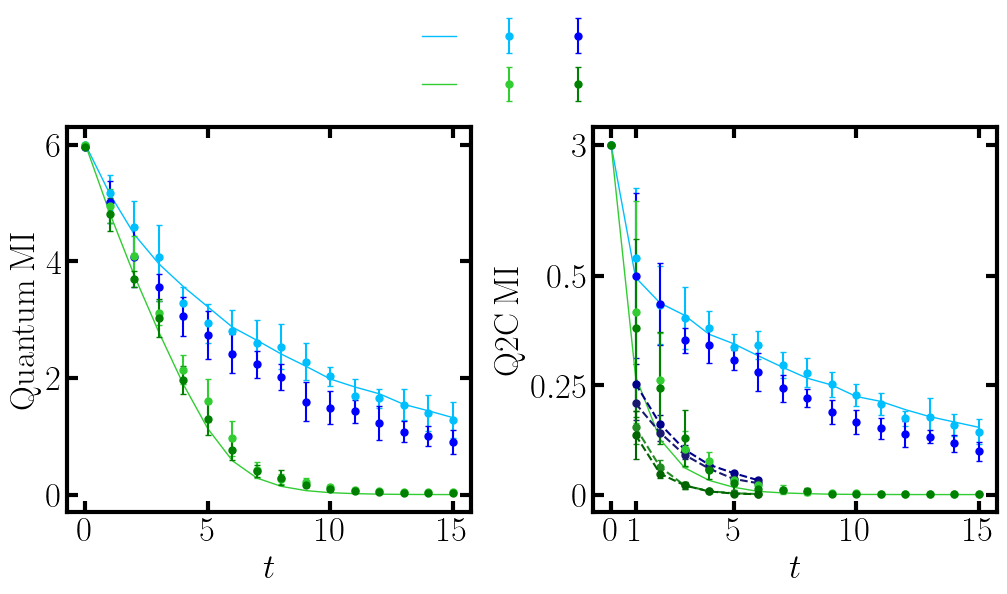

In [2]:
qmi_cond_noise_simu = np.load('data/IBM/noisy_conditioned_qmi_3Na1Nb_t0-15.npy')
qmi_cond_id = np.load('data/IBM/idea_conditioned_qmi_3Na1Nb_t0-15.npy')
qmi_cond_haar = np.load(f'data/seqModel/Na3/monitored/bell/avgMI_Na3Nb1.npz')

qmi_uncond_noise_simu = np.load('data/IBM/noisy_unconditioned_qmi_3Na1Nb_t0-15.npy')
qmi_uncond_id = np.load('data/IBM/idea_unconditioned_qmi_3Na1Nb_t0-15.npy')
qmi_uncond_haar = np.load('data/seqModel/Na3/traceout/bell/MI_Na3Nb1_traceout.npy')

q2c_cond_id = np.load(f'data/Q2C/ideal_conditioned_cmi_3Na1Nb_t0-15.npy')
q2c_cond_haar = np.load(f'data/Q2C/Q2Ccond_Na3Nb1_ex.npy')
q2c_cond_noise_simu = np.load(f'data/Q2C/noisy_conditioned_cmi_3Na1Nb_t0-15.npy')
q2c_cond_noise_simu_idl = np.load(f'data/IBM/noisy_with_idling_conditioned_cmi_n3na1T7L6.npy')
q2c_cond_noise_exp = np.load(f'data/IBM/torino_dd_conditioned_cmi_n3na1T7L6.npy')

q2c_uncond_id = np.load(f'data/Q2C/ideal_unconditioned_cmi_3Na1Nb_t0-15.npy')
q2c_uncond_haar = np.load(f'data/Q2C/Q2Cuncond_Na3Nb1_ex.npy')
q2c_uncond_noise_simu = np.load(f'data/Q2C/noisy_unconditioned_cmi_3Na1Nb_t0-15.npy')
q2c_uncond_noise_simu_idl = np.load(f'data/IBM/noisy_with_idling_unconditioned_cmi_n3na1T7L6.npy')
q2c_uncond_noise_exp = np.load(f'data/IBM/torino_dd_unconditioned_cmi_n3na1T7L6.npy')


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(qmi_cond_haar['t'][:16], qmi_cond_haar['MI'].mean(1)[:16], lw=1, c='deepskyblue', label=' ')
axs[0].errorbar(np.arange(16), qmi_cond_id.mean(0), yerr=qmi_cond_id.std(0), fmt='o', markersize=5, capsize=2,
                c='deepskyblue', label=' ')
axs[0].errorbar(np.arange(16), qmi_cond_noise_simu.mean(0), yerr=qmi_cond_noise_simu.std(0), fmt='o', markersize=5, capsize=2,
                c='b', label=' ')

axs[0].plot(qmi_uncond_haar.mean(1), lw=1, c='limegreen', label=' ')
axs[0].errorbar(np.arange(16), qmi_uncond_id.mean(0), yerr=qmi_uncond_id.std(0), fmt='o', markersize=5, capsize=2,
                c='limegreen', label=' ')
axs[0].errorbar(np.arange(16), qmi_uncond_noise_simu.mean(0), yerr=qmi_uncond_noise_simu.std(0), fmt='o', markersize=5, capsize=2,
                c='g', label=' ')

handles, labels = axs[0].get_legend_handles_labels()
order = [0, 1, 2, 4, 3, 5]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]
axs[0].legend(handles, labels, handlelength=1, handletextpad=0.5, ncol=3, columnspacing=0.5,
             loc='upper left', bbox_to_anchor=(0.8, 1.35), framealpha=0)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$\rm Quantum \: MI$')
axs[0].set_xticks([0, 5, 10, 15])

axs[1].plot(np.hstack((0.8, q2c_cond_haar.mean(1)[1:])), lw=1, c='deepskyblue')
axs[1].errorbar(np.arange(16), np.hstack((0.8, q2c_cond_id.mean(0)[1:])), yerr=q2c_cond_id.std(0), fmt='o', markersize=5, 
                capsize=2, c='deepskyblue')
axs[1].errorbar(np.arange(16), np.hstack((0.8, q2c_cond_noise_simu.mean(0)[1:])), yerr=q2c_cond_noise_simu.std(0), fmt='o', markersize=5, 
                capsize=2, c='b')
axs[1].errorbar(np.arange(1, 7), q2c_cond_noise_simu_idl.mean(0)[1:], yerr=q2c_cond_noise_simu_idl.std(0)[1:], fmt='o--', 
                markersize=5, capsize=2, c='darkblue')
axs[1].errorbar(np.arange(1, 7), q2c_cond_noise_exp.mean(0)[1:], yerr=q2c_cond_noise_exp.std(0)[1:], fmt='o--', 
                markersize=5, capsize=2, c='midnightblue')

axs[1].plot(np.hstack((0.8, q2c_uncond_haar.mean(1)[1:])), lw=1, c='limegreen')
axs[1].errorbar(np.arange(16), np.hstack((0.8, q2c_uncond_id.mean(0)[1:])), yerr=q2c_uncond_id.std(0), fmt='o', markersize=5, 
                capsize=2, c='limegreen')
axs[1].errorbar(np.arange(16), np.hstack((0.8, q2c_uncond_noise_simu.mean(0)[1:])), yerr=q2c_uncond_noise_simu.std(0), fmt='o', markersize=5, 
                capsize=2, c='g')
axs[1].errorbar(np.arange(1, 7), q2c_uncond_noise_simu_idl.mean(0)[1:], yerr=q2c_uncond_noise_simu_idl.std(0)[1:], fmt='o--', 
                markersize=5, capsize=2, c='forestgreen')
axs[1].errorbar(np.arange(1, 7), q2c_uncond_noise_exp.mean(0)[1:], yerr=q2c_uncond_noise_exp.std(0)[1:], fmt='o--', 
                markersize=5, capsize=2, c='darkgreen')

axs[1].set_xlabel(r'$t$')
axs[1].set_ylabel(r'$\rm Q2C \: MI$')
axs[1].set_yticks([0, 0.25, 0.5, 0.8])
axs[1].set_yticklabels(['$0$', '$0.25$', '$0.5$', '$3$'])
axs[1].set_xticks([0, 1, 5, 10, 15])
for i in range(2):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

plt.subplots_adjust(wspace=0.3)

#plt.savefig('figures/qmi_simu.svg', bbox_inches='tight')
plt.show()
plt.close()

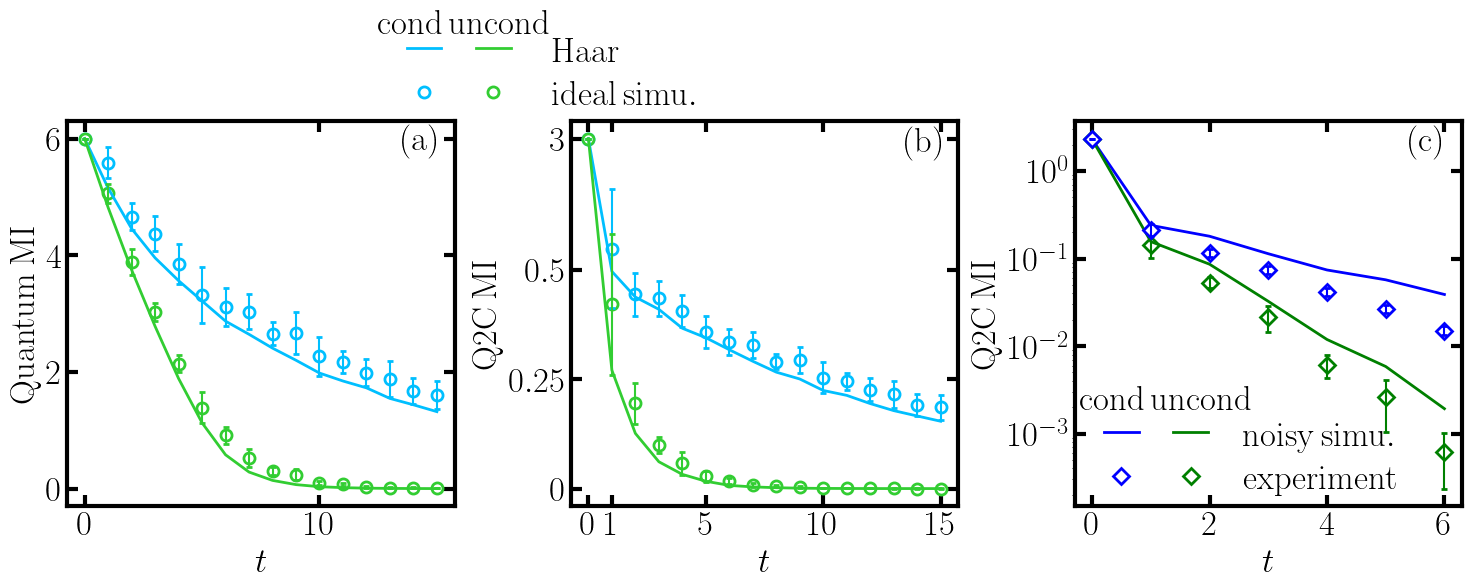

In [131]:
qmi_cond_id = np.load('data/Q2C/ideal_dm_cond_qmi_n3na1T16L4.npy')
qmi_uncond_id = np.load('data/Q2C/ideal_dm_uncond_qmi_n3na1T16L4.npy')

qmi_cond_haar = np.load(f'data/seqModel/Na3/monitored/bell/avgMI_Na3Nb1.npz')
qmi_uncond_haar = np.load('data/seqModel/Na3/traceout/bell/MI_Na3Nb1_traceout.npy')

q2c_cond_id = np.load('data/Q2C/ideal_dm_cond_cmi_n3na1T16L4.npy')
q2c_uncond_id = np.load('data/Q2C/ideal_dm_uncond_cmi_n3na1T16L4.npy')

q2c_cond_haar = np.load(f'data/Q2C/Q2Ccond_Na3Nb1_ex.npy')
q2c_uncond_haar = np.load(f'data/Q2C/Q2Cuncond_Na3Nb1_ex.npy')

q2c_cond_noise_simu = np.load(f'data/Q2C/noisy_meas_cond_cmi_n3na1T7L4.npy')
q2c_uncond_noise_simu = np.load(f'data/Q2C/noisy_meas_uncond_cmi_n3na1T7L4.npy')

q2c_cond_noise_exp = np.load(f'data/Q2C/torino_dd_meas_cond_cmi_n3na1T7L4.npy')
q2c_uncond_noise_exp = np.load(f'data/Q2C/torino_dd_meas_uncond_cmi_n3na1T7L4.npy')


fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].errorbar(np.arange(16), qmi_cond_id.mean(0), yerr=qmi_cond_id.std(0), fmt='o', markersize=8, 
                mfc='white', barsabove=True, markeredgewidth=2, capsize=2, c='deepskyblue')
axs[0].plot(qmi_cond_haar['MI'].mean(1)[:16], lw=2, c='deepskyblue')
axs[0].errorbar(np.arange(16), qmi_uncond_id.mean(0), yerr=qmi_uncond_id.std(0), fmt='o', markersize=8, 
                mfc='white', barsabove=True, markeredgewidth=2, capsize=2, c='limegreen')
axs[0].plot(qmi_uncond_haar.mean(1), lw=2, c='limegreen')
axs[0].set_ylabel(r'$\rm Quantum\:MI$')
axs[0].set_xlabel(r'$t$')

p_line_lb   = mlines.Line2D([], [], linestyle='-',  color='deepskyblue', linewidth=2)
p_line_lg = mlines.Line2D([], [], linestyle='-',  color='limegreen', linewidth=2)

p_dot_lb = mlines.Line2D([], [], linestyle='None', marker='o',
                           markersize=8, markerfacecolor='white',
                           markeredgecolor='deepskyblue', markeredgewidth=2)
p_dot_lg = mlines.Line2D([], [], linestyle='None', marker='o',
                             markersize=8, markerfacecolor='white',
                             markeredgecolor='limegreen', markeredgewidth=2)
handles = [
    (p_line_lb, p_line_lg),   # line light color
    (p_dot_lb, p_dot_lg),      # circle light color
]
labels = [r'$\rm Haar$', r'$\rm ideal\:simu.$']
axs[0].legend(
    handles, labels,
    handler_map={tuple: HandlerTuple(ndivide=2, pad=1.)},
    handlelength=3, handleheight=0.9,
    handletextpad=1.2, labelspacing=0.3, borderpad=0.35,
    framealpha=0., loc='upper left', bbox_to_anchor=(0.8, 1.3)
)
axs[0].text(12.5, 7.8, r'$\rm cond$')
axs[0].text(15.5, 7.8, r'$\rm uncond$')

axs[1].errorbar(np.arange(16), np.hstack((0.8, q2c_cond_id.mean(0)[1:])), yerr=q2c_cond_id.std(0), fmt='o', markersize=8, 
                mfc='white', barsabove=True, markeredgewidth=2, capsize=2, c='deepskyblue')
axs[1].plot(np.hstack((0.8, q2c_cond_haar.mean(1)[1:])), lw=2, c='deepskyblue')
axs[1].errorbar(np.arange(16), np.hstack((0.8, q2c_uncond_id.mean(0)[1:])), yerr=q2c_uncond_id.std(0), fmt='o', markersize=8, 
                mfc='white', barsabove=True, markeredgewidth=2, capsize=2, c='limegreen')
axs[1].plot(np.hstack((0.8, q2c_uncond_haar.mean(1)[1:])), lw=2, c='limegreen')
axs[1].set_xlabel(r'$t$')
axs[1].set_ylabel(r'$\rm Q2C \: MI$')
axs[1].set_yticks([0, 0.25, 0.5, 0.8])
axs[1].set_yticklabels(['$0$', '$0.25$', '$0.5$', '$3$'])
axs[1].set_xticks([0, 1, 5, 10, 15])

axs[2].plot(np.arange(7), q2c_cond_noise_simu.mean(0), lw=2, c='b')
axs[2].errorbar(np.arange(7), q2c_cond_noise_exp.mean(0), yerr=q2c_cond_noise_exp.std(0), fmt='D', markersize=8, 
                mfc='white', barsabove=True, markeredgewidth=2, capsize=2, c='b', zorder=5)
axs[2].plot(np.arange(7), q2c_uncond_noise_simu.mean(0), lw=2, c='g')
axs[2].errorbar(np.arange(7), q2c_uncond_noise_exp.mean(0), yerr=q2c_uncond_noise_exp.std(0), fmt='D', markersize=8, 
                mfc='white', barsabove=True, markeredgewidth=2, capsize=2, c='g')
axs[2].set_yscale('log')
axs[2].set_ylabel(r'$\rm Q2C \: MI$')
axs[2].set_xlabel(r'$t$')
axs[2].set_xticks(range(0, 7, 2))

p_line_b = mlines.Line2D([], [], linestyle='-', color='b', lw=2)
p_line_g = mlines.Line2D([], [], linestyle='-', color='g', lw=2)
p_dot_b = mlines.Line2D([], [], linestyle='None', marker='D',
                           markersize=8, markerfacecolor='white',
                           markeredgecolor='b', markeredgewidth=2)
p_dot_g = mlines.Line2D([], [], linestyle='None', marker='D',
                             markersize=8, markerfacecolor='white',
                             markeredgecolor='g', markeredgewidth=2)
handles = [
    (p_line_b, p_line_g),   # line light color
    (p_dot_b, p_dot_g),      # circle light color
]
labels = [r'$\rm noisy\:simu.$', r'$\rm experiment$']
axs[2].legend(
    handles, labels,
    handler_map={tuple: HandlerTuple(ndivide=2, pad=1)},
    handlelength=3, handleheight=0.9,
    handletextpad=1., labelspacing=0.3, borderpad=0.35,
    framealpha=0., loc='lower left', bbox_to_anchor=(0, -0.05)
)

axs[2].text(-0.2, 1.9e-3, r'$\rm cond$')
axs[2].text(1., 1.9e-3, r'$\rm uncond$')

plt.subplots_adjust(wspace=0.3)
for i in range(3):
    axs[i].tick_params(direction='in', top='on', right='on', length=8, width=3)

axs[0].text(13.5, 5.8, r'$\rm (a)$')
axs[1].text(13.5, 0.77, r'$\rm (b)$')
axs[2].text(5.4, 1.7, r'$\rm (c)$')

plt.savefig('figures/q2c.pdf', bbox_inches='tight')
plt.show()
plt.close()

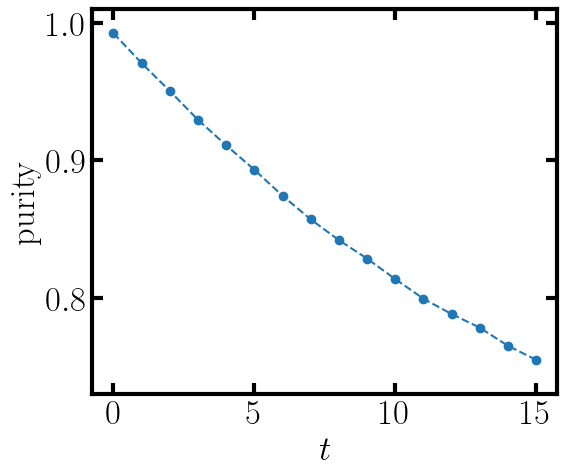

In [167]:
qmi_cond_purity = np.load('data/IBM/noisy_conditioned_purity_3Na1Nb_t0-15.npy')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(np.arange(16), qmi_cond_purity.mean(0), 'o--')
ax.set_ylabel(r'$\rm purity$')
ax.set_xlabel(r'$t$')
ax.set_ylim(0.73, 1.01)
ax.tick_params(direction='in', top='on', right='on', length=8, width=3)
plt.savefig('figures/purity_simu.pdf', bbox_inches='tight')
plt.show()
plt.close()